In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.pendulum import (
    PendulumMultiTrajectoryGLSConfig,
    generate_pendulum_dataset,
    run_pendulum_multi_trajectory_gls_experiment,
)
from mfsindy.cases.pendulum_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]

cfg = PendulumMultiTrajectoryGLSConfig(
    n_runs=5,
    results_dir=str(RESULTS_DIR),
    results_filename="pendulum_part1_errors.csv",
)


# Linear Pendulum Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the linear pendulum system using the multi-trajectory (Part 1) workflow.

## Governing Equations

The damped linear pendulum dynamics are

$$
\begin{align*}
\dot{\theta} &= \omega, \\
\dot{\omega} &= -\frac{b}{m}\omega - \frac{g}{L}\theta,
\end{align*}
$$

where $\theta$ is the angular displacement, $\omega$ is the angular velocity, $b$ is the damping coefficient, $m$ is the mass, $g$ is the gravitational acceleration, and $L$ is the pendulum length.

We use parameters $\left(\frac{b}{m}, \frac{g}{L}\right)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories. We assume:
$$
\frac{b}{m}=0.5 \qquad \text{and} \qquad \frac{g}{L} = 1
$$

### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

In [ ]:
print(
    f"Running Part 1 pendulum experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _,
    _,
    _,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_pendulum_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)



Running Part 1 pendulum experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo pendulum MF: 100%|██████████| 5/5 [01:51<00:00, 22.35s/it]


In [3]:
print("Mean Absolute Error")
print(mae_summary)


Mean Absolute Error
         median       q25       q75
model                              
HF     0.264689  0.018774  0.265601
LF     0.173488  0.123590  0.186510
MF     0.086660  0.073191  0.175836
MF_w   0.006205  0.006184  0.008056


In [4]:
print("Support Fraction Error")
print(l0_summary)


Support Fraction Error
         median       q25       q75
model                              
HF     0.333333  0.000000  0.333333
LF     0.333333  0.333333  0.333333
MF     0.333333  0.000000  0.333333
MF_w   0.000000  0.000000  0.000000


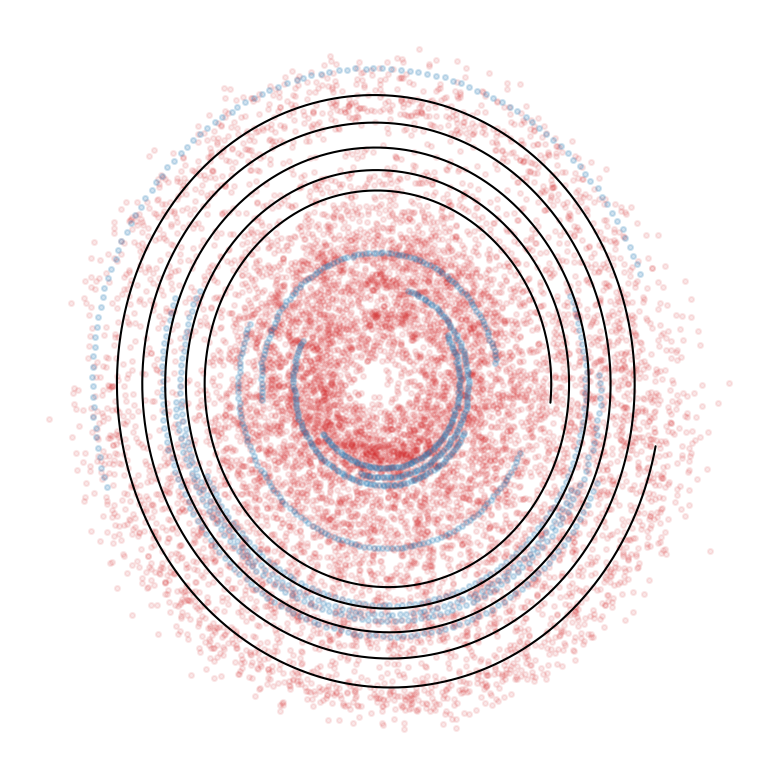

In [5]:
# regenerate HF / LF datasets using the *absolute* noise levels from MF experiment
X_hf_noisy, t_train, _ = generate_pendulum_dataset(
    n_traj=cfg.n_hf,
    T=1,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base,
)

X_lf_noisy, _, _ = generate_pendulum_dataset(
    n_traj=cfg.n_lf,
    T=1,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base+100,
)

# long clean reference trajectory (no noise)
X_ref, _, _ = generate_pendulum_dataset(
    n_traj=1,
    T=10.0,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base+10,
)

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

# LF trajectories (noisy) – red
for X in X_lf_noisy:
    ax.plot(
        X[::10, 0],
        X[::10, 1],
        ".",
        color="tab:red",
        alpha=0.1,
        linewidth=0.6,
    )

# HF trajectories (noisy) – blue
for X in X_hf_noisy:
    ax.plot(
        X[::10, 0],
        X[::10, 1],
        ".",
        color="tab:blue",
        alpha=0.2,
        linewidth=0.8,
    )

# Clean reference trajectory – black
ax.plot(
    X_ref[0][:, 0],
    X_ref[0][:, 1],
    "-",
    color="black",
    alpha=1.0,
    linewidth=1.0,
)

# Remove ticks and spines for a clean, compact panel
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

plt.tight_layout(pad=0.05)
plt.show()


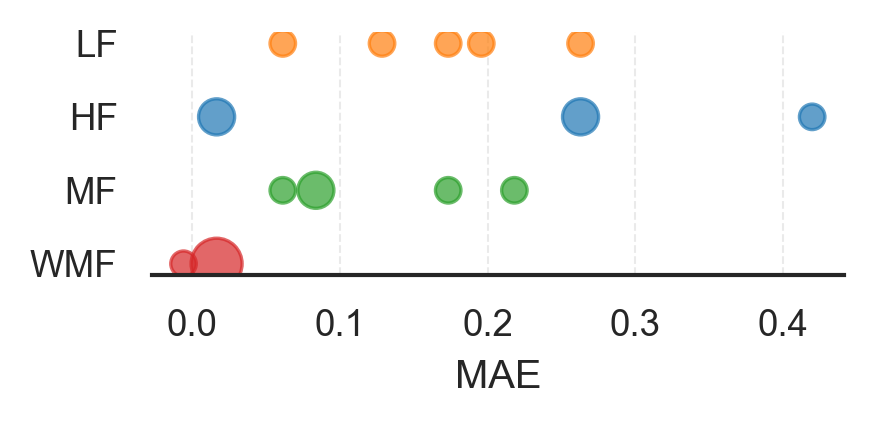

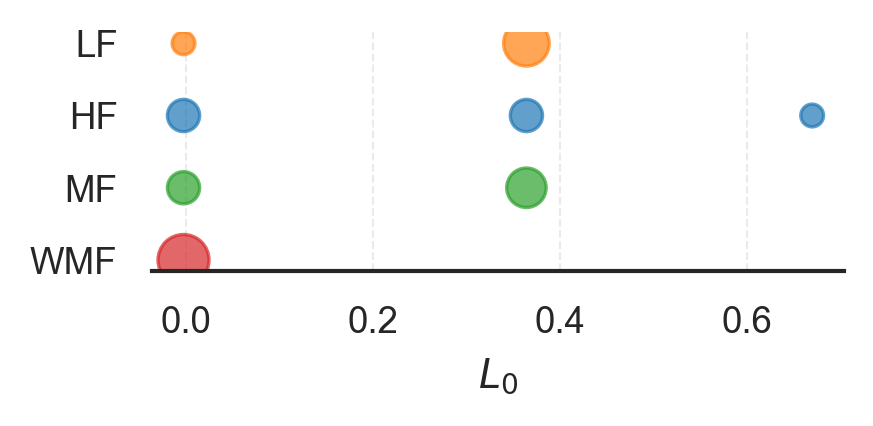

In [6]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

